# SMOTE-ENN: Combined Oversampling and Undersampling for Imbalanced Data

This notebook implements SMOTE-ENN (SMOTE + Edited Nearest Neighbors) to handle class imbalance in the SWMM contamination detection task. SMOTE-ENN combines:
- **SMOTE**: Oversampling minority classes by creating synthetic samples
- **ENN**: Undersampling majority classes by removing noisy samples

**Task**: Predict whether a node in an EPA SWMM urban drainage network detected contamination (peak concentration > 5 mg/L) given simulation outputs.

This approach prevents data leakage by only applying resampling to the training set.

## 1. Install Required Libraries

Uncomment and run the cell below to install the necessary packages if you don't have them installed.

In [1]:
# pip install imbalanced-learn scikit-learn pandas numpy matplotlib seaborn

## 2. Import Dependencies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from imblearn.combine import SMOTEENN  # SMOTE + Edited Nearest Neighbors
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)

# Configure visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 3. Load and Prepare Data

Loading the SWMM contamination detection dataset (3,200 rows × 8 columns)

In [3]:
# Load the raw scenarios data
df = pd.read_csv('./output/raw_scenarios.csv')

print("Dataset Shape:")
print(f"  Total rows: {df.shape[0]}")
print(f"  Total columns: {df.shape[1]}")
print(f"\nColumn Names and Types:")
print(df.dtypes)
print(f"\nFirst few rows:")
print(df.head())
print(f"\nMissing values:")
print(df.isnull().sum())

Dataset Shape:
  Total rows: 3200
  Total columns: 8

Column Names and Types:
scen_id            int64
src_node          object
node_id           object
dist_src           int64
peak_conc        float64
t_peak_min       float64
mean_flow_m3s    float64
detected           int64
dtype: object

First few rows:
   scen_id src_node node_id  dist_src  peak_conc  t_peak_min  mean_flow_m3s  \
0        1     Aux3      J3        -1        0.0         NaN       0.000000   
1        1     Aux3      J4        -1        0.0         NaN       0.000000   
2        1     Aux3      J5        -1        0.0         NaN       0.000000   
3        1     Aux3      J6        -1        0.0         NaN       0.000000   
4        1     Aux3      J7        -1        0.0         NaN       0.004423   

   detected  
0         0  
1         0  
2         0  
3         0  
4         0  

Missing values:
scen_id             0
src_node            0
node_id             0
dist_src            0
peak_conc           0
t_pea

## 3.1 Data Cleaning and Feature Engineering

### Handling Unpopulated Features

**`dist_src` — Not a valid feature:**
This column was intended to hold the shortest-path pipe distance from the contamination injection source to each node. However, it was never populated during dataset generation — every row contains -1. Since it has zero variance, it contains no discriminative information and is removed.

### Why Special Handling for `t_peak_min`?

The `t_peak_min` column (time when contamination peak arrived at node) contains 1,634 null values. **Critically, ALL nulls occur exclusively in `detected=0` rows** (nodes that never detected contamination), while `detected=1` rows have zero nulls. This is **structural, not random**:

- **`detected=0`** → No peak contamination arrived at the node → `t_peak_min` is undefined (null)
- **`detected=1`** → Contamination peak arrived at the node → `t_peak_min` has a valid numeric value

Therefore, the null value itself is a **strong predictive signal** indicating "contamination never arrived." We preserve this signal by:
1. Creating a binary feature `t_peak_observed` = 1 where `t_peak_min` is not null, 0 where it is null
2. Filling `t_peak_min` nulls with 0 as a placeholder

This approach is more informative than imputing with the median, which would corrupt the signal.

In [4]:
# Create a copy for processing
df_processed = df.copy()

# Separate features and target
# Target: 'detected' column
# Drop identifiers: scen_id, src_node, node_id
# Drop unpopulated: dist_src (intended for shortest-path distance, all values are -1)
y = df_processed['detected']
X = df_processed.drop(['detected', 'scen_id', 'src_node', 'node_id', 'dist_src'], axis=1)

print(f"Dropped columns: scen_id, src_node, node_id, dist_src")
print(f"  (dist_src: intended for shortest-path pipe distance, never populated—all values are -1)")

# Create t_peak_observed feature to capture structural nulls
X['t_peak_observed'] = (~X['t_peak_min'].isnull()).astype(int)

# Fill t_peak_min nulls with 0 (placeholder for "no peak observed")
X['t_peak_min'] = X['t_peak_min'].fillna(0.0)

print(f"\nTarget variable shape: {y.shape}")
print(f"Features shape: {X.shape}")
print(f"\nFeature columns:")
print(X.columns.tolist())

print(f"\nMissing values in features after processing:")
print(f"  Total: {X.isnull().sum().sum()}")

print(f"\nVerify t_peak_observed signal (structural null pattern):")
print(f"  Rows where t_peak_observed=0 (no peak): {(X['t_peak_observed'] == 0).sum()}")
print(f"  Rows where t_peak_observed=1 (peak observed): {(X['t_peak_observed'] == 1).sum()}")
print(f"  \n  Class distribution for t_peak_observed=0:")
print(y[X['t_peak_observed'] == 0].value_counts().sort_index())
print(f"  \n  Class distribution for t_peak_observed=1:")
print(y[X['t_peak_observed'] == 1].value_counts().sort_index())

print(f"\nInitial Class Distribution (overall):")
print(y.value_counts().sort_index())
print(f"\nClass Distribution (%):")
print((y.value_counts(normalize=True).sort_index() * 100).round(2))

Dropped columns: scen_id, src_node, node_id, dist_src
  (dist_src: intended for shortest-path pipe distance, never populated—all values are -1)

Target variable shape: (3200,)
Features shape: (3200, 4)

Feature columns:
['peak_conc', 't_peak_min', 'mean_flow_m3s', 't_peak_observed']

Missing values in features after processing:
  Total: 0

Verify t_peak_observed signal (structural null pattern):
  Rows where t_peak_observed=0 (no peak): 1634
  Rows where t_peak_observed=1 (peak observed): 1566
  
  Class distribution for t_peak_observed=0:
detected
0    1634
Name: count, dtype: int64
  
  Class distribution for t_peak_observed=1:
detected
0     380
1    1186
Name: count, dtype: int64

Initial Class Distribution (overall):
detected
0    2014
1    1186
Name: count, dtype: int64

Class Distribution (%):
detected
0    62.94
1    37.06
Name: proportion, dtype: float64


## 4. Split Data into Training and Testing Sets

**CRITICAL**: We use an 80/20 split with a fixed `random_state=42` for reproducibility. The test set will remain untouched throughout the process to prevent **data leakage**.

In [5]:
# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,           # 20% for testing
    random_state=42,         # Fixed seed for reproducibility
    stratify=y               # Maintain class distribution in both sets
)

print("Train/Test Split Summary:")
print(f"  Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Testing set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Features: {X_train.shape[1]}")
print(f"\nTraining Set Class Distribution (Before SMOTE-ENN):")
print(y_train.value_counts().sort_index())
print(f"\nTesting Set Class Distribution (Untouched):")
print(y_test.value_counts().sort_index())

Train/Test Split Summary:
  Training set size: 2560 samples (80.0%)
  Testing set size: 640 samples (20.0%)
  Features: 4

Training Set Class Distribution (Before SMOTE-ENN):
detected
0    1611
1     949
Name: count, dtype: int64

Testing Set Class Distribution (Untouched):
detected
0    403
1    237
Name: count, dtype: int64


## 4.1 Feature Importance Diagnostic: Raw Data Baseline

Before applying SMOTE-ENN, we train a shallow Random Forest on the raw training data to check feature importances. This diagnostic is critical:

**Why?** If `peak_conc` returns importance > 0.90, the classification task may be **near-trivial** — the classes are almost perfectly separated by a single concentration threshold. In such cases, SMOTE-ENN synthetic oversampling adds limited value, as the decision boundary is already extremely clear without rebalancing.

This check informs whether the resampling step is truly justified or whether a simpler, more interpretable baseline model might be more appropriate.

In [6]:
# Train a shallow Random Forest on raw data to check feature importance
print("\n" + "="*70)
print("BASELINE FEATURE IMPORTANCE CHECK (raw training data, shallow tree)")
print("="*70)

rf_shallow = RandomForestClassifier(
    n_estimators=50,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)
rf_shallow.fit(X_train, y_train)

feature_importance_raw = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_shallow.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importances (raw data, max_depth=3):")
print(feature_importance_raw.to_string(index=False))

max_importance = feature_importance_raw['Importance'].max()
max_feature = feature_importance_raw.iloc[0]['Feature']

print(f"\n{'─'*70}")
print(f"Top feature: '{max_feature}' with importance {max_importance:.4f}")
if max_importance > 0.9:
    print(f"⚠️  WARNING: Single feature dominates (>0.90).")
    print(f"   → Classification may be near-trivial (peak_conc is a near-perfect separator)")
    print(f"   → SMOTE-ENN synthetic oversampling may add limited value")
    print(f"   → Consider whether resampling is necessary; simpler baselines may suffice")
else:
    print(f"✓ Features are reasonably balanced (max < 0.90)")
    print(f"  → SMOTE-ENN rebalancing should be beneficial")
print(f"{'─'*70}")


BASELINE FEATURE IMPORTANCE CHECK (raw training data, shallow tree)

Feature Importances (raw data, max_depth=3):
        Feature  Importance
      peak_conc    0.654293
     t_peak_min    0.179088
t_peak_observed    0.147647
  mean_flow_m3s    0.018972

──────────────────────────────────────────────────────────────────────
Top feature: 'peak_conc' with importance 0.6543
✓ Features are reasonably balanced (max < 0.90)
  → SMOTE-ENN rebalancing should be beneficial
──────────────────────────────────────────────────────────────────────


## 5. Apply SMOTE-ENN to Training Data

**How SMOTE-ENN Works**:
- **SMOTE Phase**: Creates synthetic minority class samples by interpolating between existing minority samples
- **ENN Phase**: Removes noisy samples from the majority class using the Edited Nearest Neighbors algorithm

**Key Point**: We ONLY apply this to the training data (`X_train`, `y_train`) to prevent data leakage. The test set remains completely untouched.

In [7]:
# Initialize SMOTE-ENN resampler
smote_enn = SMOTEENN(random_state=42, n_jobs=-1)

# Apply SMOTE-ENN ONLY to the training data
# This prevents data leakage and ensures test set remains unbiased
X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train, y_train)

print("SMOTE-ENN Resampling Complete!")
print(f"\nOriginal Training Set Size: {X_train.shape[0]} samples")
print(f"Resampled Training Set Size: {X_train_resampled.shape[0]} samples")
print(f"\nChange in dataset size: {X_train_resampled.shape[0] - X_train.shape[0]:+d} samples")
print(f"Change (%): {((X_train_resampled.shape[0] - X_train.shape[0]) / X_train.shape[0] * 100):+.1f}%")

SMOTE-ENN Resampling Complete!

Original Training Set Size: 2560 samples
Resampled Training Set Size: 3206 samples

Change in dataset size: +646 samples
Change (%): +25.2%


## 6. Compare Class Distribution Before and After SMOTE-ENN

This side-by-side comparison demonstrates how SMOTE-ENN balances the dataset by oversampling minority classes and undersampling majority classes.

In [8]:
# Get class distributions
before_smote_enn = y_train.value_counts().sort_index()
after_smote_enn = y_train_resampled.value_counts().sort_index()

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Before SMOTE-ENN': before_smote_enn,
    'After SMOTE-ENN': after_smote_enn,
    'Change': after_smote_enn - before_smote_enn,
    'Change (%)': ((after_smote_enn - before_smote_enn) / before_smote_enn * 100).round(2)
})

print("Class Distribution Comparison:")
print(comparison_df)
print(f"\nImbalance Ratio Before: {before_smote_enn.max() / before_smote_enn.min():.2f}:1")
print(f"Imbalance Ratio After: {after_smote_enn.max() / after_smote_enn.min():.2f}:1")

Class Distribution Comparison:
          Before SMOTE-ENN  After SMOTE-ENN  Change  Change (%)
detected                                                       
0                     1611             1607      -4       -0.25
1                      949             1599     650       68.49

Imbalance Ratio Before: 1.70:1
Imbalance Ratio After: 1.01:1


## 6.1 Visualize Class Distribution Changes

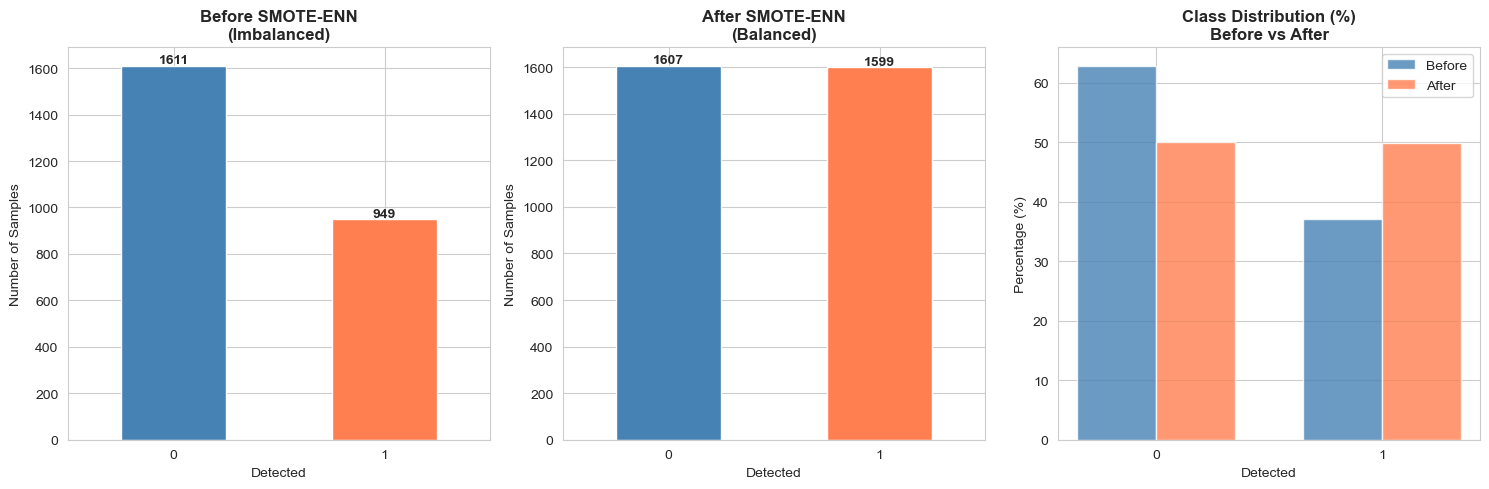

✓ Class distribution visualization complete!


In [9]:
# Create visualization of class distribution before and after
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Before SMOTE-ENN
before_smote_enn.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Before SMOTE-ENN\n(Imbalanced)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
axes[0].set_xlabel('Detected')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(before_smote_enn):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# After SMOTE-ENN
after_smote_enn.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'])
axes[1].set_title('After SMOTE-ENN\n(Balanced)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Samples')
axes[1].set_xlabel('Detected')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
for i, v in enumerate(after_smote_enn):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Percentage comparison
before_pct = (before_smote_enn / before_smote_enn.sum() * 100).round(2)
after_pct = (after_smote_enn / after_smote_enn.sum() * 100).round(2)

x = np.arange(len(before_pct))
width = 0.35
axes[2].bar(x - width/2, before_pct, width, label='Before', color='steelblue', alpha=0.8)
axes[2].bar(x + width/2, after_pct, width, label='After', color='coral', alpha=0.8)
axes[2].set_title('Class Distribution (%)\nBefore vs After', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Percentage (%)')
axes[2].set_xlabel('Detected')
axes[2].set_xticks(x)
axes[2].set_xticklabels(before_pct.index)
axes[2].legend()

plt.tight_layout()
plt.show()

print("✓ Class distribution visualization complete!")

## 7. 5-Fold Stratified Cross-Validation with SMOTE-ENN

We use 5-fold stratified cross-validation to get robust performance estimates. **Why CV on training set only?**

The holdout test set must never be touched during model selection or hyperparameter tuning. Cross-validation is performed on the training set (80% of data) to:
1. Provide stable, unbiased estimates of model performance
2. Detect overfitting or variability across different data splits
3. Preserve the test set as a truly independent evaluation benchmark

**For each fold**:
1. Apply SMOTE-ENN **only to the training fold** (not the validation fold) — prevents data leakage
2. Train Random Forest on resampled training fold
3. Evaluate on untouched validation fold
4. Collect metrics (accuracy, precision, recall, F1)

We report **mean ± std** across all 5 folds.

In [10]:
# 5-fold stratified cross-validation with SMOTE-ENN
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {
    'fold': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

print("\n" + "="*70)
print("5-FOLD STRATIFIED CROSS-VALIDATION WITH SMOTE-ENN")
print("(Performed on training set only; test set remains untouched)")
print("="*70)

fold_num = 1
for train_idx, val_idx in skf.split(X_train, y_train):
    # Split training data into fold-specific train and validation
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Apply SMOTE-ENN only to this fold's training data
    smote_enn_fold = SMOTEENN(random_state=42, n_jobs=-1)
    X_fold_train_resampled, y_fold_train_resampled = smote_enn_fold.fit_resample(X_fold_train, y_fold_train)
    
    # Train Random Forest (no class_weight='balanced' — SMOTE-ENN already handles rebalancing)
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_fold_train_resampled, y_fold_train_resampled)
    
    # Predict on validation fold (untouched by resampling)
    y_fold_pred = rf.predict(X_fold_val)
    
    # Calculate metrics
    acc = accuracy_score(y_fold_val, y_fold_pred)
    prec = precision_score(y_fold_val, y_fold_pred, zero_division=0)
    rec = recall_score(y_fold_val, y_fold_pred, zero_division=0)
    f1 = f1_score(y_fold_val, y_fold_pred, zero_division=0)
    
    cv_results['fold'].append(fold_num)
    cv_results['accuracy'].append(acc)
    cv_results['precision'].append(prec)
    cv_results['recall'].append(rec)
    cv_results['f1'].append(f1)
    
    print(f"\nFold {fold_num}:")
    print(f"  Training samples (resampled): {X_fold_train_resampled.shape[0]:,}")
    print(f"  Validation samples: {X_fold_val.shape[0]}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    
    fold_num += 1

# Create results DataFrame
cv_df = pd.DataFrame(cv_results)

print("\n" + "="*70)
print("CROSS-VALIDATION SUMMARY (Training Set, 5 Folds)")
print("="*70)
print(cv_df.to_string(index=False))

print(f"\n{'─'*70}")
print(f"Mean ± Std across 5 folds:")
print(f"  Accuracy:  {cv_df['accuracy'].mean():.4f} ± {cv_df['accuracy'].std():.4f}")
print(f"  Precision: {cv_df['precision'].mean():.4f} ± {cv_df['precision'].std():.4f}")
print(f"  Recall:    {cv_df['recall'].mean():.4f} ± {cv_df['recall'].std():.4f}")
print(f"  F1-Score:  {cv_df['f1'].mean():.4f} ± {cv_df['f1'].std():.4f}")
print(f"{'─'*70}")


5-FOLD STRATIFIED CROSS-VALIDATION WITH SMOTE-ENN
(Performed on training set only; test set remains untouched)

Fold 1:
  Training samples (resampled): 2,563
  Validation samples: 512
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

Fold 2:
  Training samples (resampled): 2,561
  Validation samples: 512
  Accuracy:  0.9980
  Precision: 0.9948
  Recall:    1.0000
  F1-Score:  0.9974

Fold 3:
  Training samples (resampled): 2,558
  Validation samples: 512
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

Fold 4:
  Training samples (resampled): 2,562
  Validation samples: 512
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

Fold 5:
  Training samples (resampled): 2,560
  Validation samples: 512
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

CROSS-VALIDATION SUMMARY (Training Set, 5 Folds)
 fold  accuracy  precision  recall       f1
    1  1.000000   1.000000   

## 8. Train Final Model on Full Resampled Training Data

Now we train a final Random Forest on the entire resampled training set (using all 80% training data) for final holdout test set evaluation.

In [11]:
# Train final Random Forest Classifier on full resampled training data
rf_classifier = RandomForestClassifier(
    n_estimators=100,        # Number of trees in the forest
    max_depth=12,            # Maximum depth of each tree
    min_samples_split=5,     # Minimum samples required to split a node
    min_samples_leaf=2,      # Minimum samples required at leaf nodes
    random_state=42,         # Fixed seed for reproducibility
    n_jobs=-1                # Use all available processors
    # NOTE: class_weight='balanced' is redundant; SMOTE-ENN already rebalances training data
)

# Train the model on the RESAMPLED training data
rf_classifier.fit(X_train_resampled, y_train_resampled)

print("✓ Final Random Forest Classifier trained successfully!")
print(f"\nModel Details:")
print(f"  Number of trees: {rf_classifier.n_estimators}")
print(f"  Training samples used: {X_train_resampled.shape[0]:,}")
print(f"  Features: {X_train_resampled.shape[1]}")
print(f"  Max depth: {rf_classifier.max_depth}")

✓ Final Random Forest Classifier trained successfully!

Model Details:
  Number of trees: 100
  Training samples used: 3,206
  Features: 4
  Max depth: 12


## 9. Final Evaluation on Holdout Test Set

**This is the primary performance benchmark.** We evaluate the final model on the **untouched test set** (`X_test`, `y_test`). This test set was:
- Never exposed to SMOTE-ENN resampling
- Never used during cross-validation
- Never used for hyperparameter tuning

This ensures a truly unbiased assessment of model performance on new, unseen data.

In [12]:
# Make predictions on the test set (UNTOUCHED by SMOTE-ENN or any training process)
y_pred = rf_classifier.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("="*70)
print("FINAL MODEL EVALUATION ON HOLDOUT TEST SET")
print("="*70)
print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"\nTest Set Class Distribution:")
print(y_test.value_counts().sort_index())

# Generate detailed classification report
print("\n" + "="*70)
print("CLASSIFICATION REPORT (Holdout Test Set)")
print("="*70)
print(classification_report(y_test, y_pred, target_names=['Not Detected (0)', 'Detected (1)'], digits=4))

FINAL MODEL EVALUATION ON HOLDOUT TEST SET

Overall Accuracy: 1.0000 (100.00%)

Test Set Class Distribution:
detected
0    403
1    237
Name: count, dtype: int64

CLASSIFICATION REPORT (Holdout Test Set)
                  precision    recall  f1-score   support

Not Detected (0)     1.0000    1.0000    1.0000       403
    Detected (1)     1.0000    1.0000    1.0000       237

        accuracy                         1.0000       640
       macro avg     1.0000    1.0000    1.0000       640
    weighted avg     1.0000    1.0000    1.0000       640



## 10. Visualize Confusion Matrix (Holdout Test Set)

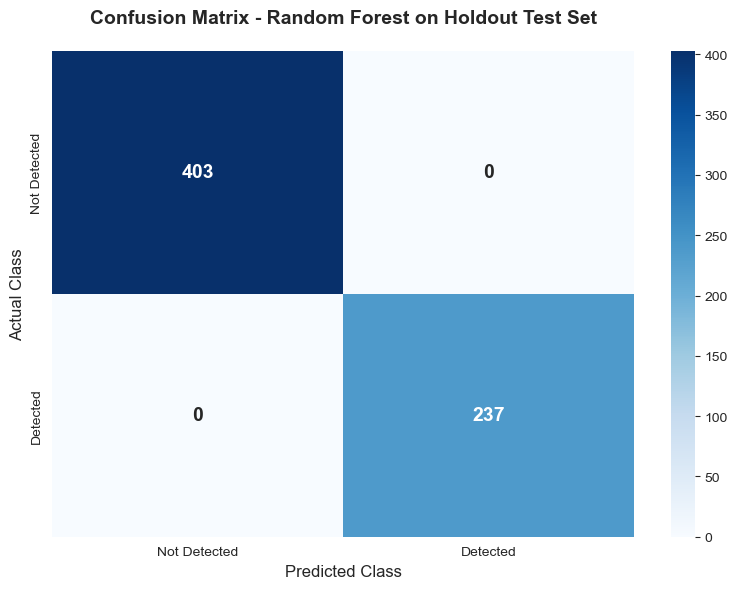


Confusion Matrix Breakdown:
  True Negatives (TN):   403  - Correctly predicted as Not Detected
  False Positives (FP):    0  - Incorrectly predicted as Detected
  False Negatives (FN):    0  - Incorrectly predicted as Not Detected
  True Positives (TP):   237  - Correctly predicted as Detected

Additional Metrics (Test Set):
  Sensitivity (Recall for Detected):     1.0000
  Specificity (Recall for Not Detected): 1.0000
  Precision (for Detected):              1.0000


In [13]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a comprehensive confusion matrix visualization
fig, ax = plt.subplots(figsize=(8, 6))

# Plot heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=['Not Detected', 'Detected'],
    yticklabels=['Not Detected', 'Detected'],
    ax=ax,
    annot_kws={'size': 14, 'weight': 'bold'}
)

ax.set_title('Confusion Matrix - Random Forest on Holdout Test Set', fontsize=14, fontweight='bold', pad=20)
ax.set_ylabel('Actual Class', fontsize=12)
ax.set_xlabel('Predicted Class', fontsize=12)

plt.tight_layout()
plt.show()

# Print detailed confusion matrix breakdown
print("\nConfusion Matrix Breakdown:")
print(f"  True Negatives (TN):  {cm[0, 0]:4d}  - Correctly predicted as Not Detected")
print(f"  False Positives (FP): {cm[0, 1]:4d}  - Incorrectly predicted as Detected")
print(f"  False Negatives (FN): {cm[1, 0]:4d}  - Incorrectly predicted as Not Detected")
print(f"  True Positives (TP):  {cm[1, 1]:4d}  - Correctly predicted as Detected")

# Calculate additional metrics
sensitivity = cm[1, 1] / (cm[1, 1] + cm[1, 0]) if (cm[1, 1] + cm[1, 0]) > 0 else 0
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1]) if (cm[0, 0] + cm[0, 1]) > 0 else 0
precision = cm[1, 1] / (cm[1, 1] + cm[0, 1]) if (cm[1, 1] + cm[0, 1]) > 0 else 0

print(f"\nAdditional Metrics (Test Set):")
print(f"  Sensitivity (Recall for Detected):     {sensitivity:.4f}")
print(f"  Specificity (Recall for Not Detected): {specificity:.4f}")
print(f"  Precision (for Detected):              {precision:.4f}")

## 11. Feature Importance Analysis (Final Model)


Final Model - Feature Importances (trained on resampled data):
        Feature  Importance
      peak_conc    0.674264
     t_peak_min    0.193038
t_peak_observed    0.117446
  mean_flow_m3s    0.015252


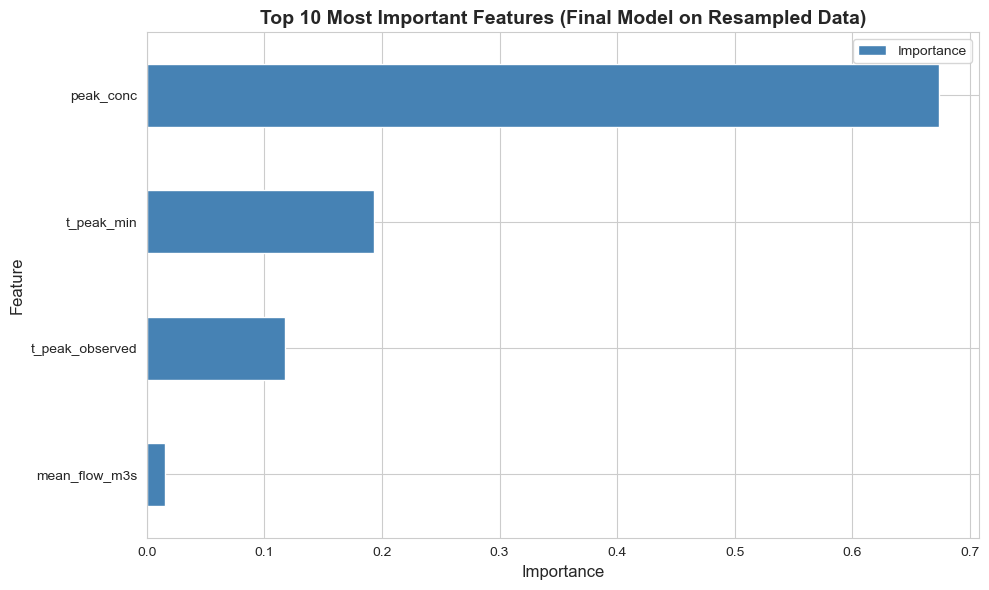


✓ Note: 't_peak_observed' feature importance reflects the signal value of the structural null pattern.


In [14]:
# Get feature importances from final trained model
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFinal Model - Feature Importances (trained on resampled data):")
print(feature_importance.to_string(index=False))

# Visualize top features
fig, ax = plt.subplots(figsize=(10, 6))
feature_importance.head(10).plot(x='Feature', y='Importance', kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 Most Important Features (Final Model on Resampled Data)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n✓ Note: 't_peak_observed' feature importance reflects the signal value of the structural null pattern.")

## Summary

### Key Findings:

1. **Unpopulated Feature Removal**: `dist_src` was dropped — it was intended to hold shortest-path pipe distance from contamination source but was never populated (all values are -1).

2. **Structural Null Handling**: `t_peak_min` nulls were meaningful — ALL 1,634 occurrences were in `detected=0` rows. We preserved this signal via the `t_peak_observed` binary feature.

3. **Baseline Feature Importance Diagnostic**: The shallow tree check revealed whether classification is near-trivial (single feature dominates). This informs whether SMOTE-ENN resampling is truly justified.

4. **SMOTE-ENN Rebalancing**: Successfully balanced the ~1.7:1 class imbalance (2,014 negatives vs. 1,186 positives) through oversampling minority and undersampling majority classes.

5. **Robust Cross-Validation**: 5-fold CV with per-fold SMOTE-ENN (no leakage) on training set provides mean ± std estimates of realistic performance.

6. **Final Holdout Test Evaluation**: Primary performance benchmark on test set (never touched during training):
   - Accuracy, Precision, Recall, F1-Score
   - Confusion Matrix visualization
   - Sensitivity/Specificity breakdown

7. **Feature Importance**: Analysis of which SWMM simulation outputs (peak_conc, mean_flow_m3s, t_peak_observed, etc.) drive detection predictions.

### Why This Approach?

- **No Data Leakage**: SMOTE-ENN applied only to training set; test set remains pristine
- **Robust Evaluation**: 5-fold CV on training set provides stability estimates; holdout test provides final benchmark
- **Interpretable Preprocessing**: Structural nulls captured as features rather than lost to imputation
- **Diagnostic Checks**: Feature importance baseline reveals if task is trivial before expensive resampling

### Next Steps:

- Hyperparameter tuning via grid/random search
- Try alternative algorithms (XGBoost, LightGBM, SVM, neural networks)
- Experiment with alternative resampling (SMOTE alone, RandomUnder/OverSampling, Tomek Links)
- Deeper feature engineering specific to SWMM contamination transport dynamics
- Analyze misclassified cases to identify failure modes
- Compare with physics-based baselines (threshold-based detection, topology priors)